# Automatic Prompt Optimization Across Model Families
### Six methods, eight models, one protocol — a lean, reproducible comparison

Prompt choice can move small-model accuracy by dozens of points, and a growing family of *automatic prompt optimization* (APO) methods competes to find those prompts. Published APO results are rarely comparable across papers: different models, budgets, seeds, harnesses. This study removes that noise. Eight methods — our proposed **SWIFT** (curated fixed schedule) and **APEX** (UCB1 bandit scheduling), their data-driven **SWIFTv2**/**APEXv2** variants, plus paper-faithful reimplementations of **CAPO, GAAPO, GEPA,** and **SEE** — run under a single protocol: same seeds, same seed prompts, same budget caps, same evaluation harness, each method keeping only its own paper-specific hyperparameters.

**Four research questions drive every section below — nothing is here that doesn't answer one of them:**

> **RQ1 — Outcome.** Which method is most accurate across models, and do the differences survive statistical scrutiny?
> **RQ2 — Cost.** What does each method's accuracy cost in LLM calls and dollars?
> **RQ3 — Generalization.** Does the best method depend on the base model, or the base model's scale?
> **RQ4 — Mechanism.** On the one head-to-head design difference (fixed schedule vs. adaptive bandit), which wins and when?

**Reporting standards:** every number aggregates all completed seeds (42, 123, 7) — no cherry-picking (Bouthillier et al. 2021). Every mean ships with uncertainty: standard deviation *and* bootstrap 95% CI. Every significance test ships with an effect size, never a p-value alone (Dror et al. 2018). Rank-based tests use only balanced (model, task) blocks where every compared method has all seeds — nothing incomplete is silently averaged in. Every figure regenerates from the raw run artifacts on disk (`result_*.json` + `audit_*.json`), so this notebook stays current as pending runs land.


---
## 1 · Data, protocol, and honest scope

**Loading.** Every run on disk becomes rows in two dataframes: `runs` (one row per model/method/task/seed — final scores, budget, timing) and `traj` (one row per optimization generation — best/mean dev score, timestamp; powers §6). Loading is defensive: malformed files are collected into `load_errors` instead of crashing.

In [1]:
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.labelsize": 11.5,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "legend.fontsize": 10, "legend.title_fontsize": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
    "figure.constrained_layout.use": False,
    "figure.autolayout": False,
})

RNG = np.random.default_rng(0)  # fixed bootstrap seed -> reproducible CIs

def tl():
    """tight_layout that never crashes on layout-engine conflicts."""
    try:
        plt.tight_layout()
    except Exception:
        pass

def legend_right(ax, title=None):
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.02), frameon=False,
              title=title, borderaxespad=0)

def shared_top_legend(fig, axes_list, ncol=6, y=1.0):
    """One figure-level legend on top; removes duplicated per-axes legends."""
    h, l = axes_list[0].get_legend_handles_labels()
    for ax in axes_list:
        lg = ax.get_legend()
        if lg is not None:
            lg.remove()
    fig.legend(h, l, ncol=ncol, loc="lower center",
               bbox_to_anchor=(0.5, y), frameon=False)

OUTPUTS = Path("..") / "outputs"

METHODS = ["swift", "apex", "capo", "gaapo", "gepa", "see", "swift_v2", "apex_v2"]
METHOD_LABEL = {"swift": "SWIFT", "apex": "APEX", "capo": "CAPO",
                "gaapo": "GAAPO", "gepa": "GEPA", "see": "SEE",
                "swift_v2": "SWIFTv2", "apex_v2": "APEXv2"}
PALETTE = dict(zip(METHODS, sns.color_palette("colorblind", len(METHODS))))
LPALETTE = {METHOD_LABEL[m]: c for m, c in PALETTE.items()}

# dir-slug -> (display, size class, params in B)
MODEL_META = {
    "qwen3-4b":                ("Qwen3-4B",     "4B", 4.0),
    "llama-3.2-3b-instruct":   ("Llama-3.2-3B", "4B", 3.2),
    "phi-4-mini-instruct":     ("Phi-4-mini",   "4B", 3.8),
    "gemma-3-4b-it":           ("Gemma3-4B",    "4B", 4.0),
    "llama-3.1-8b-instruct":   ("Llama-3.1-8B", "8B", 8.0),
    "gemma-7b-it":             ("Gemma-7B",     "8B", 7.0),
    "qwen3-8b":                ("Qwen3-8B",     "8B", 8.2),
    # Same base checkpoint as Qwen3-4B, but a DIFFERENT experimental config
    # (population_size=8 vs. 5, different num_iterations) -- merging it into
    # "Qwen3-4B" would silently average two incomparable configs together, so
    # it gets its own distinct label and column instead. It does have the full
    # 8-task extended BBH set complete, unlike the primary "Qwen3-4B" (4/8).
    "qwen3-4b-instruct-2507":  ("Qwen3-4B (pop8)", "4B", 4.0),
}
MODEL_VENDOR = {"Qwen3-4B": "Qwen", "Qwen3-4B (pop8)": "Qwen", "Qwen3-8B": "Qwen",
                "Llama-3.2-3B": "Meta", "Llama-3.1-8B": "Meta",
                "Phi-4-mini": "Microsoft",
                "Gemma3-4B": "Google", "Gemma-7B": "Google"}
MODEL_ORDER = ["Qwen3-4B", "Qwen3-4B (pop8)", "Llama-3.2-3B", "Phi-4-mini", "Gemma3-4B",
               "Llama-3.1-8B", "Gemma-7B", "Qwen3-8B"]
SIZE_CLASS = {"Qwen3-4B": "4B", "Qwen3-4B (pop8)": "4B", "Llama-3.2-3B": "4B",
              "Phi-4-mini": "4B", "Gemma3-4B": "4B", "Llama-3.1-8B": "8B",
              "Gemma-7B": "8B", "Qwen3-8B": "8B"}

# (source dir, flat model slug or None for <model>/<method>/<task>/<seed> layout)
SOURCES = [
    (OUTPUTS / "proposal_comparison_3bench_qwen3-4-instruct", "qwen3-4b"),
    (OUTPUTS / "multi_model_cot_4bs", None),
    (OUTPUTS / "multi_model_4bs", None),
    (OUTPUTS / "multi_model_cot_8bs", None),
]

BBH_TASKS = ["bbh_causal_judgement", "bbh_disambiguation_qa",
             "bbh_formal_fallacies", "bbh_hyperbaton"]
# The 4 core tasks above are complete for all 8 models -- used everywhere a
# cross-model macro/CD/Bradley-Terry comparison needs a consistent metric.
# The 4 extra tasks below are only complete for 2 of 8 models so far
# (Phi-4-mini, Qwen3-4B (pop8)) -- used ONLY in the per-task breakdown (2.1),
# never in the cross-model headline sections, since mixing them into the
# macro would silently drop the other 6 models from every table.
BBH_TASKS_EXTENDED = BBH_TASKS + [
    "bbh_boolean_expressions", "bbh_logical_deduction_five_objects",
    "bbh_reasoning_about_colored_objects", "bbh_web_of_lies",
]
TASK_SHORT = {"bbh_causal_judgement": "CJ", "bbh_disambiguation_qa": "DQ",
              "bbh_formal_fallacies": "FF", "bbh_hyperbaton": "HY",
              "bbh_boolean_expressions": "BoolExpr",
              "bbh_logical_deduction_five_objects": "LogicDed5",
              "bbh_reasoning_about_colored_objects": "ColorObj",
              "bbh_web_of_lies": "WebLies",
              "gsm8k": "GSM8K", "humaneval": "HumanEval"}

def benchmark_of(task):
    return "bbh" if task.startswith("bbh_") else task

def boot_ci(values, n_boot=10000, alpha=0.05):
    """Percentile bootstrap CI for the mean of `values`."""
    v = np.asarray([x for x in values if x is not None and not np.isnan(x)])
    if len(v) < 2:
        return (np.nan, np.nan)
    idx = RNG.integers(0, len(v), size=(n_boot, len(v)))
    means = v[idx].mean(axis=1)
    return (float(np.percentile(means, 100 * alpha / 2)),
            float(np.percentile(means, 100 * (1 - alpha / 2))))

def cliffs_delta(a, b):
    """Cliff's delta effect size of a over b, with magnitude label."""
    a, b = np.asarray(a), np.asarray(b)
    gt = sum((x > b).sum() for x in a)
    lt = sum((x < b).sum() for x in a)
    d = (gt - lt) / (len(a) * len(b))
    ad = abs(d)
    mag = ("negligible" if ad < 0.147 else "small" if ad < 0.33
           else "medium" if ad < 0.474 else "large")
    return float(d), mag

def holm_correct(pdict):
    """Holm step-down correction on a dict {key: raw_p} -> {key: adj_p}."""
    items = sorted(pdict.items(), key=lambda kv: kv[1])
    m = len(items)
    out, running = {}, 0.0
    for r, (k, pv) in enumerate(items):
        running = max(running, min(1.0, (m - r) * pv))
        out[k] = running
    return out

def expected_max_curve(vals, ns):
    """Dodge et al. 2019 estimator: E[max of n i.i.d. draws] from observed vals."""
    v = np.sort(np.asarray([x for x in vals if x is not None and not np.isnan(x)]))
    N = len(v)
    if N == 0:
        return [np.nan] * len(ns)
    hi = np.arange(1, N + 1) / N
    lo = np.arange(0, N) / N
    return [float(np.sum(v * (hi ** n - lo ** n))) for n in ns]

print("Toolkit ready.")

Toolkit ready.


**Coverage.** Every table and test below draws only from cells where all 3 seeds completed — this cell computes that inventory once, so nothing downstream needs to re-derive it.

In [2]:
run_rows, traj_rows, load_errors = [], [], []

for src, flat_slug in SOURCES:
    if not src.exists():
        continue
    for f in sorted(src.rglob("result_*.json")):
        rel = f.relative_to(src).parts
        try:
            if flat_slug and len(rel) == 4:
                slug, method, task, seed_dir = flat_slug, rel[0], rel[1], rel[2]
            elif len(rel) == 5:
                slug, method, task, seed_dir = rel[0], rel[1], rel[2], rel[3]
            else:
                continue
            if method not in METHODS:
                continue
            model, size_class, params = MODEL_META.get(slug, (slug, "?", np.nan))
            seed = int(seed_dir.replace("seed_", ""))
            d = json.loads(f.read_text(encoding="utf-8"))
            u = d.get("llm_usage", {}) or {}
            run_rows.append(dict(
                model=model, size_class=size_class, params_b=params,
                method=method, task=task, benchmark=benchmark_of(task), seed=seed,
                test_score=d.get("test_score"), best_dev=d.get("best_score"),
                calls=u.get("total_calls"), tokens=u.get("total_tokens"),
                llm_time=u.get("total_time_seconds"), total_time=d.get("total_time"),
            ))
            for h in d.get("optimization_history") or []:
                traj_rows.append(dict(
                    model=model, method=method, task=task,
                    benchmark=benchmark_of(task), seed=seed,
                    generation=h.get("generation"), best_score=h.get("best_score"),
                    timestamp=h.get("timestamp"),
                ))
        except Exception as e:
            load_errors.append((str(f), repr(e)))

runs = pd.DataFrame(run_rows)
traj = pd.DataFrame(traj_rows)
runs["Method"] = runs["method"].map(METHOD_LABEL)
if not traj.empty:
    traj["Method"] = traj["method"].map(METHOD_LABEL)

# Models actually in scope for the headline comparison. "Qwen3-4B (pop8)"
# (qwen3-4b-instruct-2507) is its own column, not merged into "Qwen3-4B" --
# same checkpoint, different experimental config (see MODEL_META note above).
models_present = [m for m in MODEL_ORDER if m in runs.model.unique()]
excluded_models = sorted(set(runs.model.unique()) - set(MODEL_ORDER))

print(f"runs: {len(runs)}   trajectory rows: {len(traj)}   load errors: {len(load_errors)}")
print(f"In-scope models ({len(models_present)}): {models_present}")
if excluded_models:
    print(f"Loaded but excluded from the comparison: {excluded_models}")
if load_errors:
    for f_, e_ in load_errors[:5]:
        print("  !", f_, e_)

exp_seeds = 3
cov = (runs[runs.model.isin(models_present)]
       .groupby(["model", "Method", "task"])["seed"].nunique()
       .rename("seeds").reset_index())

complete_bbh = {}
for model in models_present:
    ok = []
    for m in METHODS:
        s = cov[(cov.model == model) & (cov.Method == METHOD_LABEL[m]) &
                (cov.task.isin(BBH_TASKS)) & (cov.seeds >= exp_seeds)]
        if len(s) == len(BBH_TASKS):
            ok.append(m)
    complete_bbh[model] = ok

cov_rows = []
for model in MODEL_ORDER:
    row = {"Model": model}
    for m in METHODS:
        row[METHOD_LABEL[m]] = "\u2705" if m in complete_bbh.get(model, []) else "\u274c"
    cov_rows.append(row)
print("\nBBH (4-task) coverage -- \u2705 = all 3 seeds complete for all 4 tasks:")
display(pd.DataFrame(cov_rows).set_index("Model"))

GH_MODELS = [m for m in ["Qwen3-4B", "Llama-3.2-3B"]
             if not runs[(runs.model == m) & (runs.benchmark.isin(["gsm8k", "humaneval"]))].empty]
print(f"\nGSM8K/HumanEval: clean 6-method coverage only for {GH_MODELS} -- \u00a7 5 is scoped to these models only.")
print("SVAMP: not yet run anywhere in outputs/ -- excluded from this notebook entirely (not fabricated).")
print(f"GEPA: absent from the primary Qwen3-4B study (5-method baseline there); "
      f"present in the multi-model runs. \u00a7 2 handles this via a fallback config (see below).")

runs: 807   trajectory rows: 3793   load errors: 0
In-scope models (8): ['Qwen3-4B', 'Qwen3-4B (pop8)', 'Llama-3.2-3B', 'Phi-4-mini', 'Gemma3-4B', 'Llama-3.1-8B', 'Gemma-7B', 'Qwen3-8B']

BBH (4-task) coverage -- ✅ = all 3 seeds complete for all 4 tasks:


,SWIFT,APEX,CAPO,GAAPO,GEPA,SEE,SWIFTv2,APEXv2
Model,,,,,,,,
Qwen3-4B,✅,✅,✅,✅,❌,✅,❌,❌
Qwen3-4B (pop8),✅,✅,✅,✅,✅,✅,❌,❌
Llama-3.2-3B,✅,✅,✅,✅,✅,✅,❌,❌
Phi-4-mini,✅,✅,✅,✅,✅,✅,❌,❌
Gemma3-4B,✅,✅,✅,✅,✅,✅,❌,❌
Llama-3.1-8B,✅,✅,✅,✅,✅,✅,❌,❌
Gemma-7B,✅,✅,✅,✅,✅,✅,❌,❌
Qwen3-8B,✅,✅,✅,✅,✅,✅,❌,❌



GSM8K/HumanEval: clean 6-method coverage only for ['Qwen3-4B', 'Llama-3.2-3B'] -- § 5 is scoped to these models only.
SVAMP: not yet run anywhere in outputs/ -- excluded from this notebook entirely (not fabricated).
GEPA: absent from the primary Qwen3-4B study (5-method baseline there); present in the multi-model runs. § 2 handles this via a fallback config (see below).


---
## 2 · Headline comparison — BBH accuracy across 8 models *(RQ1)*

**Question: which method is most accurate, and does that hold up statistically?** Three complementary views of the same question, each answering a different part of it:

1. **Macro-accuracy heatmap** — the raw numbers, every model, every method.
2. **Critical-difference diagram** (Demsar 2006) — pools every complete (model, task) block into one Friedman test + post-hoc Nemenyi ranking. GEPA is missing from the primary Qwen3-4B study, so two configurations are tried automatically — all 6 methods over the blocks where all 6 are complete, and the 5 long-complete methods over every complete block — and whichever has more statistical power (more blocks) is shown.
3. **Bradley-Terry strength rating** (Chatbot Arena-style) — a different lens on the same pooled blocks: a latent per-method strength from pairwise win/loss outcomes, with a natural interpretable scale rather than just a rank order.

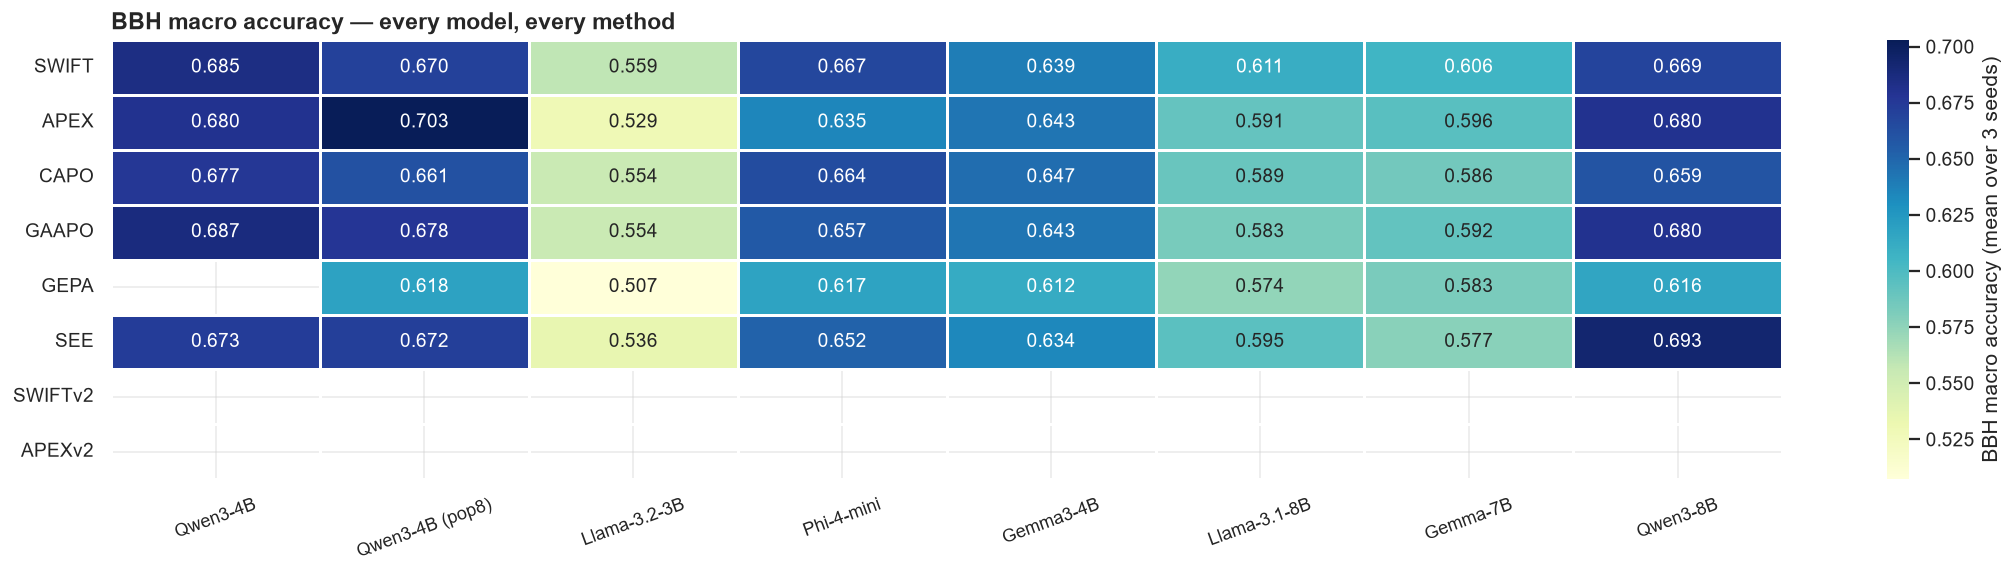

model,Qwen3-4B,Qwen3-4B (pop8),Llama-3.2-3B,Phi-4-mini,Gemma3-4B,Llama-3.1-8B,Gemma-7B,Qwen3-8B
Method,,,,,,,,
SWIFT,0.685,0.670,0.559,0.667,0.639,0.611,0.606,0.669
APEX,0.680,0.703,0.529,0.635,0.643,0.591,0.596,0.680
CAPO,0.677,0.661,0.554,0.664,0.647,0.589,0.586,0.659
GAAPO,0.687,0.678,0.554,0.657,0.643,0.583,0.592,0.680
GEPA,NaN,0.618,0.507,0.617,0.612,0.574,0.583,0.616
SEE,0.673,0.672,0.536,0.652,0.634,0.595,0.577,0.693
SWIFTv2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def bbh_macro_per_seed(df):
    rows = []
    for (model, method, seed), g in df[df.benchmark == "bbh"].groupby(["model", "method", "seed"]):
        if set(g.task) >= set(BBH_TASKS):
            rows.append(dict(model=model, method=method, seed=seed,
                             macro=g.set_index("task").loc[BBH_TASKS, "test_score"].mean()))
    return pd.DataFrame(rows)

macro = bbh_macro_per_seed(runs[runs.model.isin(models_present)])
tbl = (macro.groupby(["model", "method"])["macro"]
            .agg(mean="mean", std="std", n="count").reset_index())
tbl["Method"] = tbl.method.map(METHOD_LABEL)
pivot_mean = (tbl.pivot(index="Method", columns="model", values="mean")
                 .reindex([METHOD_LABEL[m] for m in METHODS])
                 [[m for m in MODEL_ORDER if m in tbl.model.unique()]])

fig, ax = plt.subplots(figsize=(1.9 * len(pivot_mean.columns) + 2, 4.6))
sns.heatmap(pivot_mean, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax,
            linewidths=0.6, cbar_kws={"label": "BBH macro accuracy (mean over 3 seeds)"},
            annot_kws={"fontsize": 10.5})
ax.set_title("BBH macro accuracy \u2014 every model, every method", loc="left")
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=20, labelsize=10)
tl(); plt.show()
display(pivot_mean.round(3))

### 2.1 Per-task breakdown

The macro heatmap above averages away real task-to-task variation, and is deliberately scoped to the 4 core tasks complete for all 8 models. This section shows every task each model actually has data for -- up to 8 for Phi-4-mini and Qwen3-4B (pop8) (which have the extended BBH set), 4 for the other 6 models (extended-set runs still in progress for them). Missing columns per model are a data-coverage fact, not an error -- the "Macro" column stays anchored to the same 4-task metric as §2's headline numbers either way, so it's still comparable across every model.

In [4]:
task_tbl = (runs[(runs.benchmark == "bbh") & (runs.model.isin(models_present)) &
                 (runs.task.isin(BBH_TASKS_EXTENDED))]
            .groupby(["model", "Method", "task"])["test_score"].mean()
            .rename("mean").reset_index())

for model in models_present:
    sub = task_tbl[task_tbl.model == model]
    if sub.empty:
        continue
    task_cols = [t for t in BBH_TASKS_EXTENDED if t in sub.task.unique()]
    pv = (sub.pivot(index="Method", columns="task", values="mean")
            .reindex(index=[METHOD_LABEL[m] for m in METHODS])[task_cols]
            .rename(columns=TASK_SHORT))
    if model in pivot_mean.columns:
        pv = pv.assign(**{"Macro (4-task)": pivot_mean[model].reindex(pv.index)})
    print(f"--- {model} ({len(task_cols)}/8 tasks) ---")
    display(pv.round(3))

--- Qwen3-4B (4/8 tasks) ---


task,CJ,DQ,FF,HY,Macro (4-task)
Method,,,,,
SWIFT,0.626,0.606,0.646,0.861,0.685
APEX,0.620,0.571,0.652,0.878,0.680
CAPO,0.606,0.614,0.658,0.829,0.677
GAAPO,0.626,0.591,0.675,0.855,0.687
GEPA,NaN,NaN,NaN,NaN,NaN
SEE,0.594,0.583,0.638,0.878,0.673
SWIFTv2,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN


--- Qwen3-4B (pop8) (8/8 tasks) ---


task,CJ,DQ,FF,HY,BoolExpr,LogicDed5,ColorObj,WebLies,Macro (4-task)
Method,,,,,,,,,
SWIFT,0.609,0.614,0.629,0.829,0.852,0.591,0.667,0.510,0.670
APEX,0.612,0.646,0.672,0.881,0.870,0.591,0.606,0.551,0.703
CAPO,0.649,0.533,0.629,0.832,0.829,0.594,0.635,0.557,0.661
GAAPO,0.620,0.600,0.635,0.855,0.861,0.571,0.643,0.507,0.678
GEPA,0.600,0.470,0.606,0.797,0.841,0.597,0.574,0.568,0.618
SEE,0.617,0.586,0.629,0.855,0.861,0.594,0.655,0.530,0.672
SWIFTv2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Llama-3.2-3B (4/8 tasks) ---


...

task,CJ,DQ,FF,HY,Macro (4-task)
Method,,,,,
SWIFT,0.612,0.530,0.519,0.783,0.611
APEX,0.597,0.493,0.542,0.730,0.591
CAPO,0.606,0.528,0.542,0.681,0.589
GAAPO,0.571,0.542,0.551,0.670,0.583
GEPA,0.571,0.510,0.557,0.658,0.574
SEE,0.603,0.504,0.574,0.699,0.595
SWIFTv2,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN


--- Gemma-7B (4/8 tasks) ---


task,CJ,DQ,FF,HY,Macro (4-task)
Method,,,,,
SWIFT,0.612,0.504,0.591,0.716,0.606
APEX,0.588,0.519,0.554,0.722,0.596
CAPO,0.597,0.487,0.545,0.713,0.586
GAAPO,0.594,0.510,0.528,0.736,0.592
GEPA,0.626,0.499,0.510,0.696,0.583
SEE,0.591,0.458,0.545,0.713,0.577
SWIFTv2,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN


--- Qwen3-8B (4/8 tasks) ---


task,CJ,DQ,FF,HY,Macro (4-task)
Method,,,,,
SWIFT,0.597,0.548,0.638,0.893,0.669
APEX,0.571,0.586,0.629,0.936,0.680
CAPO,0.588,0.635,0.609,0.806,0.659
GAAPO,0.606,0.565,0.638,0.913,0.680
GEPA,0.600,0.371,0.638,0.855,0.616
SEE,0.606,0.603,0.632,0.933,0.693
SWIFTv2,NaN,NaN,NaN,NaN,NaN
APEXv2,NaN,NaN,NaN,NaN,NaN


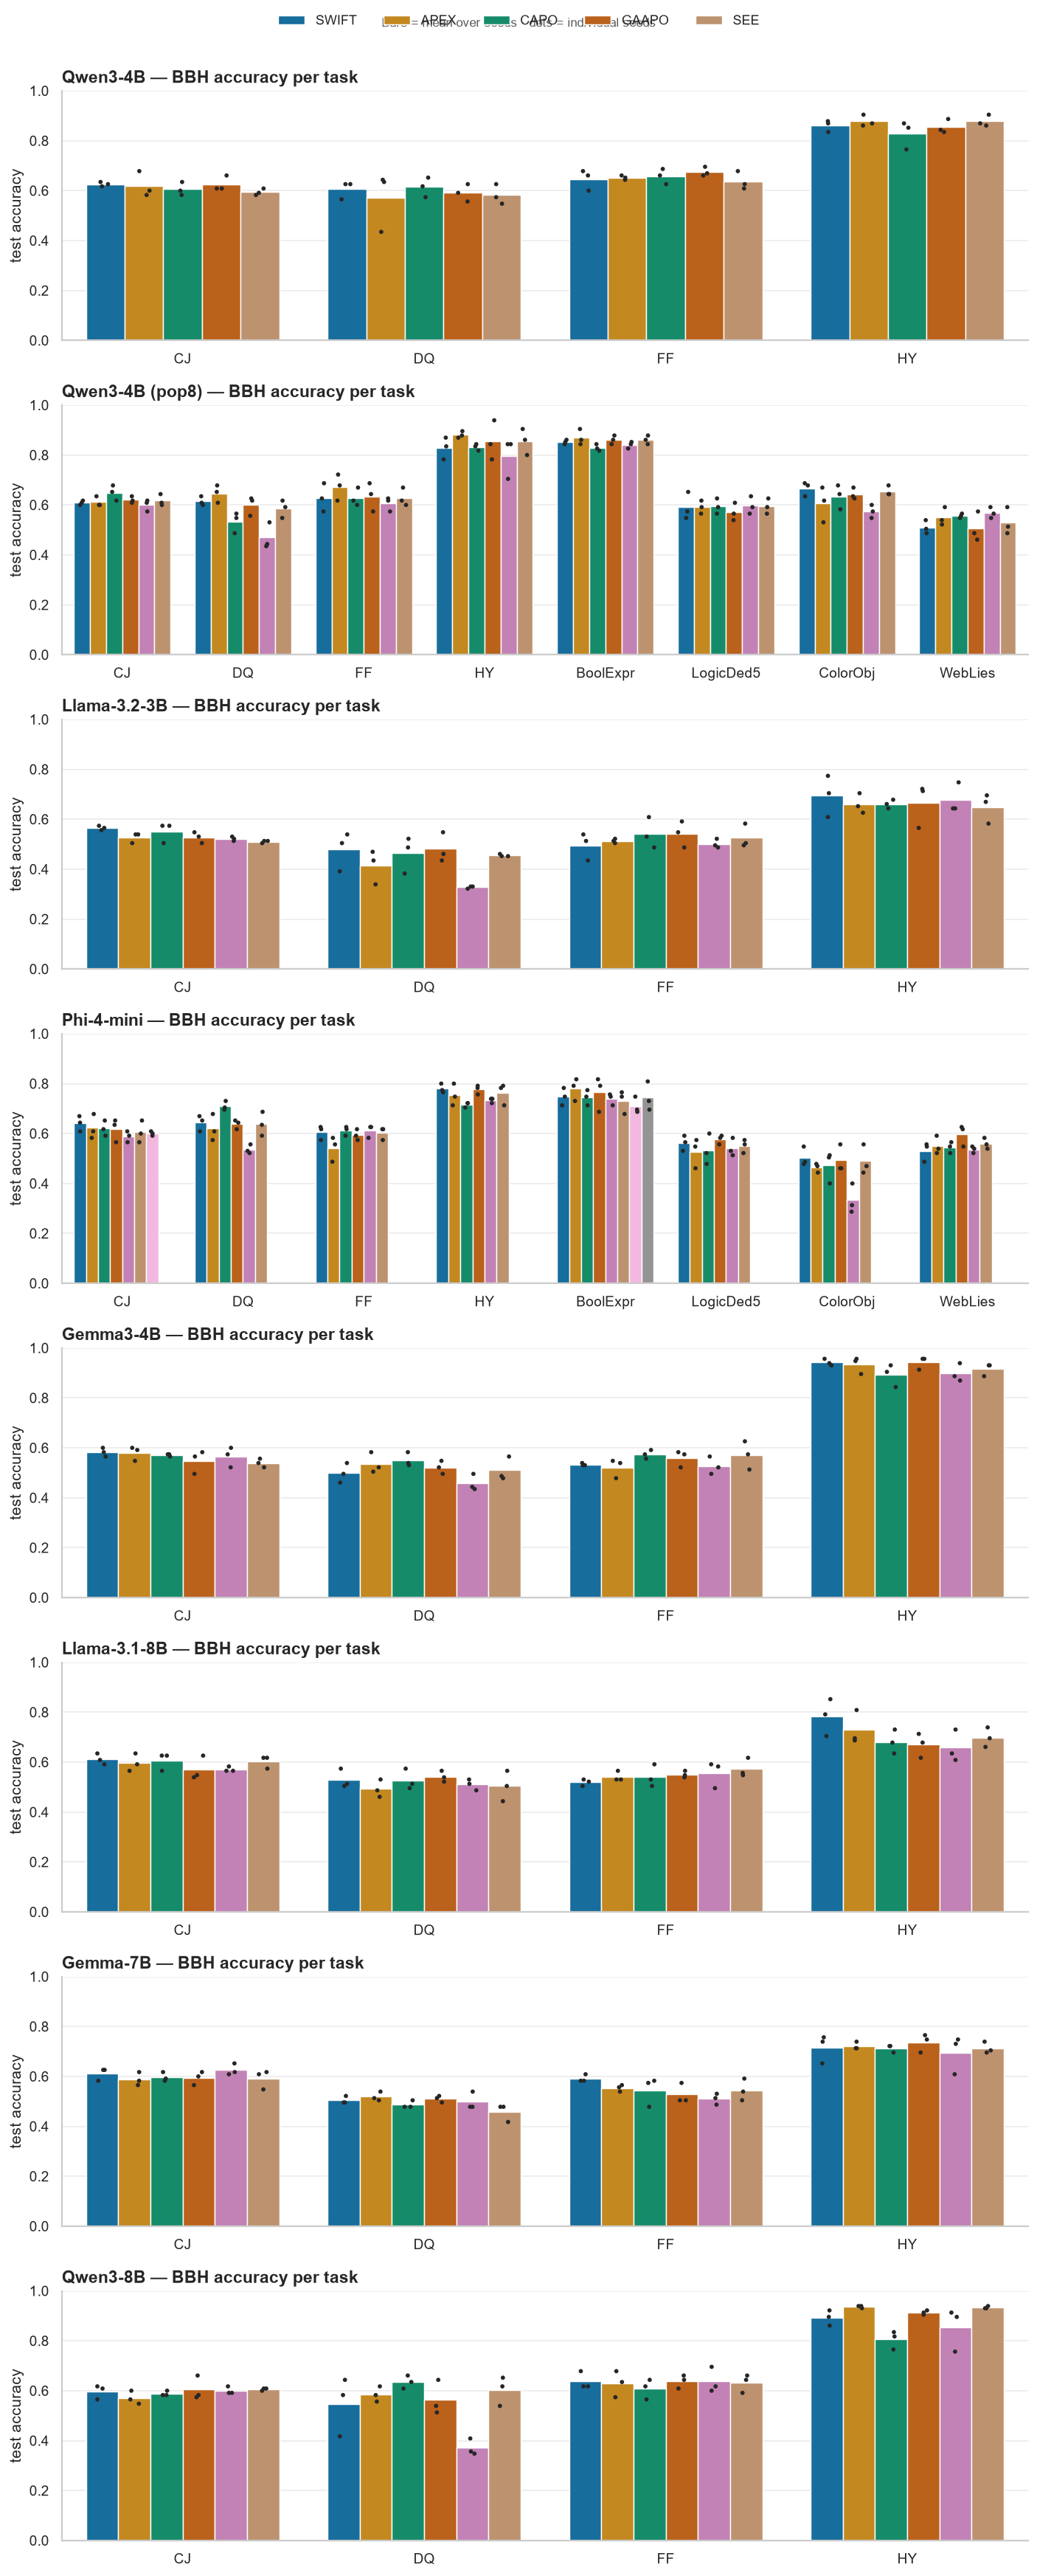

In [5]:
fig, axes = plt.subplots(len(models_present), 1,
                         figsize=(11, 3.3 * len(models_present)), squeeze=False)
plotted = []
for ax, model in zip(axes[:, 0], models_present):
    sub = runs[(runs.model == model) & (runs.benchmark == "bbh") &
               (runs.task.isin(BBH_TASKS_EXTENDED))].copy()
    if sub.empty:
        continue
    sub["Task"] = sub.task.map(TASK_SHORT)
    torder = [TASK_SHORT[t] for t in BBH_TASKS_EXTENDED if TASK_SHORT[t] in sub.Task.unique()]
    order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in sub.Method.unique()]
    sns.barplot(data=sub, x="Task", y="test_score", hue="Method", order=torder,
                hue_order=order, palette=LPALETTE, errorbar=None, ax=ax,
                edgecolor="white", linewidth=0.8)
    sns.stripplot(data=sub, x="Task", y="test_score", hue="Method", order=torder,
                  hue_order=order, dodge=True, ax=ax, color="0.15", size=3.2,
                  jitter=0.12, legend=False)
    ax.set_title(f"{model} \u2014 BBH accuracy per task", loc="left")
    ax.set_xlabel(""); ax.set_ylabel("test accuracy")
    ax.set_ylim(0, 1.0); ax.tick_params(axis="x", rotation=0)
    plotted.append(ax)
if plotted:
    shared_top_legend(fig, plotted, ncol=6, y=1.005)
    fig.text(0.5, 1.01, "Bars = mean over seeds \u00b7 dots = individual seeds",
             ha="center", fontsize=9.5, color="0.35")
tl(); plt.show()

[A: all 8 methods] not enough complete blocks.
[B: all 8 without GEPA] not enough complete blocks.
[C: v1 only, all 6]  k=6, N=36 blocks -> Friedman chi2=18.540, p=0.0023  (significant)


[D: v1 only, without GEPA]  k=5, N=40 blocks -> Friedman chi2=6.010, p=0.1984  (not significant)


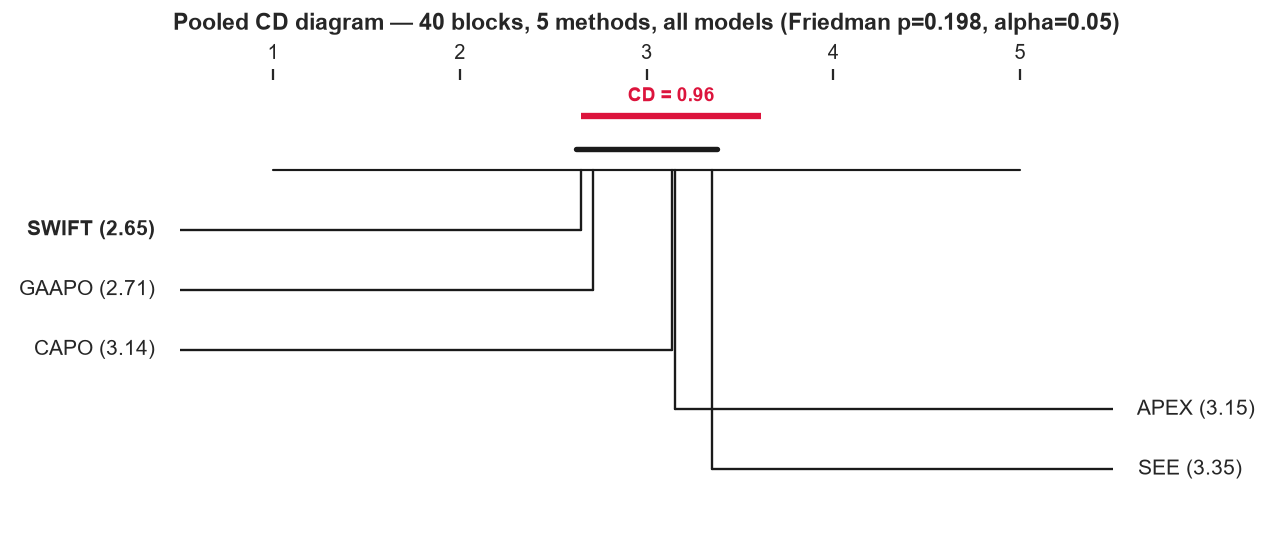

Rank order (best first): SWIFT > GAAPO > CAPO > APEX > SEE


In [6]:
Q05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031}

def friedman_blocks(df, methods, models=None):
    labels = [METHOD_LABEL[m] for m in methods]
    sub = df[df.benchmark == "bbh"]
    if models is not None:
        sub = sub[sub.model.isin(models)]
    blocks, names = [], []
    for (model, task), g in sub.groupby(["model", "task"]):
        m = g.groupby("Method")["test_score"].agg(["mean", "count"])
        if set(labels) <= set(m.index) and (m.loc[labels, "count"] >= exp_seeds).all():
            blocks.append(m.loc[labels, "mean"].values)
            names.append(f"{model}/{TASK_SHORT.get(task, task)}")
    return np.array(blocks), names, labels

def draw_cd(avg_rank, cd, p_val, title):
    """Critical-difference diagram (Demsar 2006)."""
    r = avg_rank
    k = len(r)
    fig, ax = plt.subplots(figsize=(10, 2.6 + 0.35 * k))
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(0, k + 2.5)
    ax.spines[["left", "right", "bottom"]].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.xaxis.tick_top(); ax.set_xlabel(""); ax.grid(False)
    ax.set_xticks(np.arange(1, k + 1))
    ax.tick_params(labelsize=11)
    for i, (name, rk) in enumerate(r.items()):
        y = k - i
        side = "left" if i < math.ceil(k / 2) else "right"
        tx = 0.4 if side == "left" else k + 0.6
        ha = "right" if side == "left" else "left"
        ax.plot([rk, rk], [k + 1, y], c="k", lw=1.3)
        ax.plot([rk, tx], [y, y], c="k", lw=1.3)
        ax.text(tx, y, f" {name} ({rk:.2f}) ", ha=ha, va="center",
                fontsize=11.5, fontweight="bold" if i == 0 else "normal")
    ax.plot([r.min(), r.min() + cd], [k + 1.9, k + 1.9], c="crimson", lw=3.5,
            solid_capstyle="butt")
    ax.text(r.min() + cd / 2, k + 2.15, f"CD = {cd:.2f}", ha="center",
            color="crimson", fontsize=10.5, fontweight="bold")
    yy = k + 1.35
    drawn = []
    for i in range(k):
        lo = r.iloc[i]
        grp = [j for j in range(k) if abs(r.iloc[j] - lo) <= cd and j >= i]
        if len(grp) > 1 and not any(set(grp) <= set(g) for g in drawn):
            drawn.append(grp)
            ax.plot([r.iloc[grp[0]] - 0.03, r.iloc[grp[-1]] + 0.03], [yy, yy],
                    c="k", lw=3, solid_capstyle="round")
            yy -= 0.35
    ax.plot([1, k], [k + 1, k + 1], c="k", lw=1.2)
    ax.set_title(f"{title} (Friedman p={p_val:.3f}, alpha=0.05)", pad=28)
    tl(); plt.show()

configs = {}
V1_METHODS = [m for m in METHODS if not m.endswith("_v2")]
# v2 methods (swift_v2, apex_v2) still have sparse coverage -- configs A/B
# include them so they graduate into the pooled comparison automatically as
# their data fills in, but C/D fall back to the well-established v1-only
# comparison so the CD diagram never goes empty in the meantime.
for name, mset in [("A: all 8 methods", [*METHODS]),
                   ("B: all 8 without GEPA", [m for m in METHODS if m != "gepa"]),
                   ("C: v1 only, all 6", [*V1_METHODS]),
                   ("D: v1 only, without GEPA", [m for m in V1_METHODS if m != "gepa"])]:
    Xc, bn, lb = friedman_blocks(runs[runs.model.isin(models_present)], mset)
    if len(Xc) >= 3:
        st, pv = stats.friedmanchisquare(*Xc.T)
        rk = pd.DataFrame([stats.rankdata(-row) for row in Xc], columns=lb, index=bn)
        configs[name] = dict(X=Xc, names=bn, labels=lb, stat=st, p=pv,
                             ranks=rk, avg=rk.mean().sort_values())
        print(f"[{name}]  k={len(lb)}, N={len(Xc)} blocks -> "
              f"Friedman chi2={st:.3f}, p={pv:.4f}"
              + ("  (significant)" if pv < 0.05 else "  (not significant)"))
    else:
        print(f"[{name}] not enough complete blocks.")

best_cfg = max(configs.values(), key=lambda c: len(c["X"])) if configs else None
if best_cfg:
    X, block_names, labels = best_cfg["X"], best_cfg["names"], best_cfg["labels"]
    p, ranks, avg_rank = best_cfg["p"], best_cfg["ranks"], best_cfg["avg"]
    k, N = len(labels), len(X)
    cd = Q05[k] * math.sqrt(k * (k + 1) / (6 * N))
    draw_cd(avg_rank, cd, p, f"Pooled CD diagram \u2014 {N} blocks, {k} methods, all models")
    print("Rank order (best first):", " > ".join(avg_rank.index))

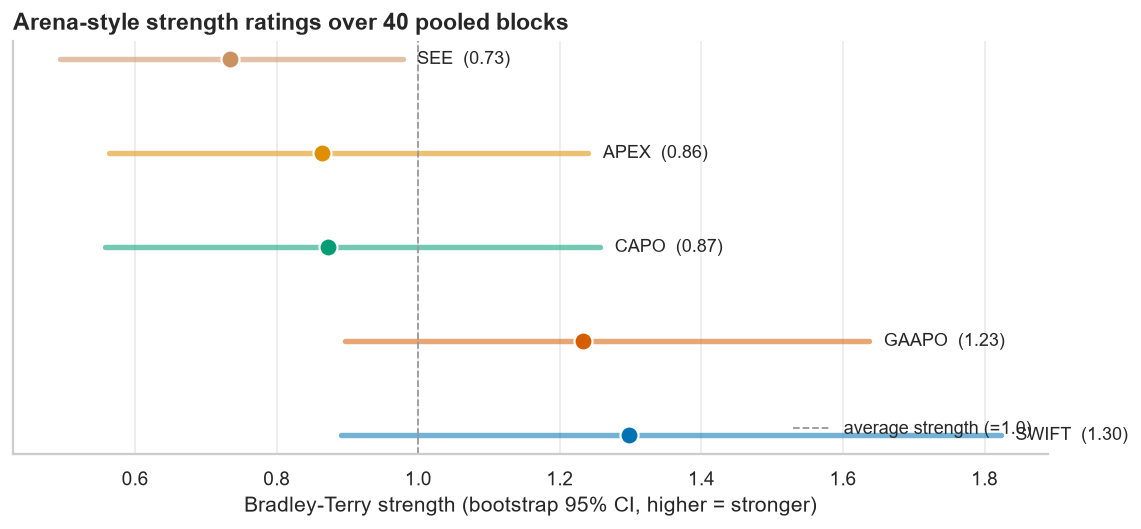

Ranking by Bradley-Terry strength: SWIFT > GAAPO > CAPO > APEX > SEE
(Usually agrees with the CD-diagram rank order; disagreements mean ties/near-ties.)


In [7]:
def bradley_terry(win_matrix, n_iter=200, eps=1e-9):
    """win_matrix[i][j] = number of times i beat j (ties pre-split 0.5/0.5)."""
    n = win_matrix.shape[0]
    w = win_matrix.sum(axis=1)
    s = np.ones(n)
    for _ in range(n_iter):
        s_new = np.zeros(n)
        for i in range(n):
            denom = sum((win_matrix[i, j] + win_matrix[j, i]) / (s[i] + s[j])
                        for j in range(n) if j != i)
            s_new[i] = w[i] / max(denom, eps)
        s_new = s_new / s_new.sum() * n
        if np.max(np.abs(s_new - s)) < eps:
            s = s_new
            break
        s = s_new
    return s

def build_win_matrix(X, labels):
    n = len(labels)
    wm = np.zeros((n, n))
    for row in X:
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                if row[i] > row[j]:
                    wm[i, j] += 1
                elif row[i] == row[j]:
                    wm[i, j] += 0.5
    return wm

if best_cfg:
    wm = build_win_matrix(X, labels)
    strength = bradley_terry(wm)
    boot_strengths = []
    for _ in range(2000):
        idx = RNG.integers(0, len(X), size=len(X))
        boot_strengths.append(bradley_terry(build_win_matrix(X[idx], labels)))
    boot_strengths = np.array(boot_strengths)
    lo = np.percentile(boot_strengths, 2.5, axis=0)
    hi = np.percentile(boot_strengths, 97.5, axis=0)

    order = np.argsort(-strength)
    fig, ax = plt.subplots(figsize=(9, 0.55 * len(labels) + 1.5))
    for rank_i, i in enumerate(order):
        ax.plot([lo[i], hi[i]], [rank_i, rank_i], c=LPALETTE[labels[i]], lw=3,
                alpha=0.55, solid_capstyle="round")
        ax.scatter(strength[i], rank_i, color=LPALETTE[labels[i]], s=100,
                   zorder=3, edgecolor="white", linewidth=1.2)
        ax.annotate(f"{labels[i]}  ({strength[i]:.2f})", (hi[i], rank_i),
                    xytext=(8, 0), textcoords="offset points", va="center", fontsize=10)
    ax.set_yticks([]); ax.axvline(1.0, c="0.6", ls="--", lw=1, label="average strength (=1.0)")
    ax.set_xlabel("Bradley-Terry strength (bootstrap 95% CI, higher = stronger)")
    ax.set_title(f"Arena-style strength ratings over {len(X)} pooled blocks", loc="left")
    ax.legend(frameon=False, loc="lower right")
    tl(); plt.show()
    print("Ranking by Bradley-Terry strength:", " > ".join(labels[i] for i in order))
    print("(Usually agrees with the CD-diagram rank order; disagreements mean ties/near-ties.)")

---
## 3 · Cost-accuracy Pareto *(RQ2)*

**Question: what does each method's accuracy cost, and which methods are worth their price?** Pooled across every model on BBH: mean LLM calls per run against mean accuracy. Points on the dashed frontier are Pareto-optimal — no other method beats them on both axes at once.

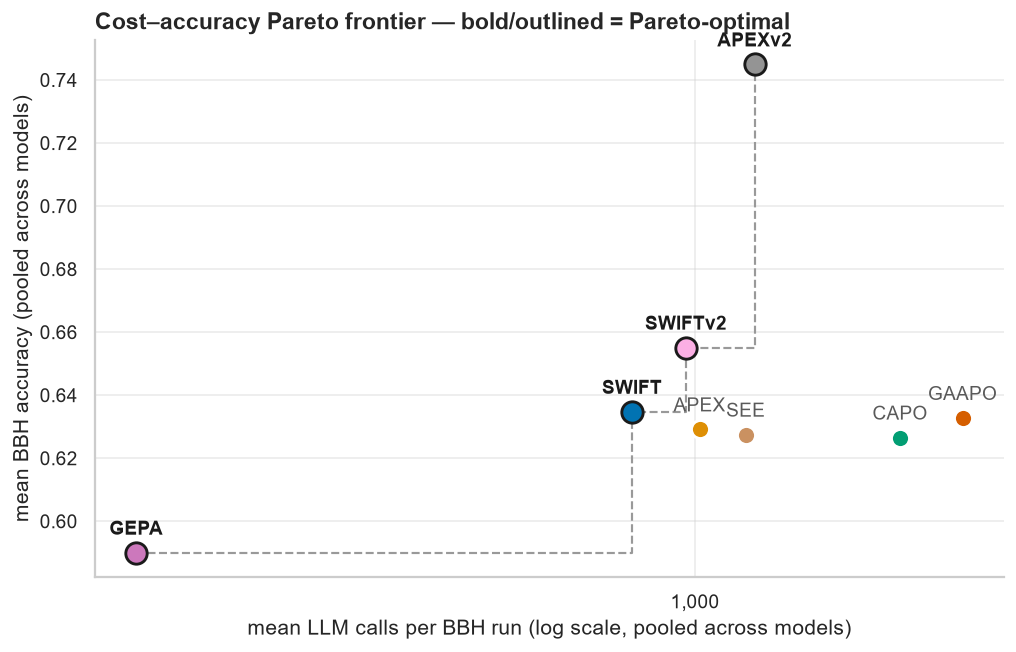

,Method,acc,calls,$/run (GPU basis),n_runs
0,SWIFT,0.635,797.0,0.038,120
1,APEX,0.629,1017.0,0.048,120
2,CAPO,0.627,2093.0,0.069,120
3,GAAPO,0.633,2622.0,0.089,120
4,GEPA,0.590,134.0,0.006,108
5,SEE,0.627,1200.0,0.044,120
6,SWIFTv2,0.655,968.0,0.024,6
7,APEXv2,0.745,1240.0,0.028,3


Cheapest: GEPA  |  Most accurate: APEXv2


In [8]:
GPU_USD_PER_HOUR = 0.30  # A4500-class marketplace rate (editable)

eff = (runs[(runs.benchmark == "bbh") & (runs.model.isin(models_present))]
       .assign(gpu_usd=lambda d: d.total_time / 3600 * GPU_USD_PER_HOUR)
       .groupby("Method")
       .agg(acc=("test_score", "mean"), calls=("calls", "mean"),
            gpu_usd=("gpu_usd", "mean"), n_runs=("seed", "size"))
       .reindex([METHOD_LABEL[m] for m in METHODS]).dropna(how="all").reset_index())

def pareto_front(df, xcol, ycol):
    keep = []
    for i, r in df.iterrows():
        if not ((df[xcol] < r[xcol]) & (df[ycol] > r[ycol])).any():
            keep.append(i)
    return keep

front = pareto_front(eff, "calls", "acc")
fig, ax = plt.subplots(figsize=(8, 5.2))
fs = eff.loc[front].sort_values("calls")
ax.step(fs.calls, fs.acc, where="post", c="0.6", lw=1.2, zorder=1, ls="--")
for i, r in eff.iterrows():
    on_front = i in front
    ax.scatter(r.calls, r.acc, color=LPALETTE[r.Method], s=140 if on_front else 100,
               edgecolor="k" if on_front else "white", linewidth=1.6, zorder=3)
    ax.annotate(r.Method, (r.calls, r.acc), fontsize=10.5,
                fontweight="bold" if on_front else "normal",
                color="0.1" if on_front else "0.35",
                xytext=(0, 10), textcoords="offset points", ha="center")
ax.set_xscale("log")
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("mean LLM calls per BBH run (log scale, pooled across models)")
ax.set_ylabel("mean BBH accuracy (pooled across models)")
ax.set_title("Cost\u2013accuracy Pareto frontier \u2014 bold/outlined = Pareto-optimal", loc="left")
tl(); plt.show()

display(eff.assign(gpu_usd=eff.gpu_usd.round(3), acc=eff.acc.round(3),
                   calls=eff.calls.round(0))
        [["Method", "acc", "calls", "gpu_usd", "n_runs"]]
        .rename(columns={"gpu_usd": "$/run (GPU basis)"}))
print(f"Cheapest: {eff.loc[eff.calls.idxmin(), 'Method']}  |  "
      f"Most accurate: {eff.loc[eff.acc.idxmax(), 'Method']}")

---
## 4 · Does the best method depend on the base model? *(RQ3)*

**Question: of model choice and method choice, which one actually moves the accuracy needle?** A standard unweighted-means two-way ANOVA on BBH macro scores (model x method) — an approximate but standard technique for unbalanced factorial designs, since GEPA has fewer complete models than the other five. A large interaction term means the *identity* of the best method genuinely shifts with the base model, not just that ranks wobble a little.

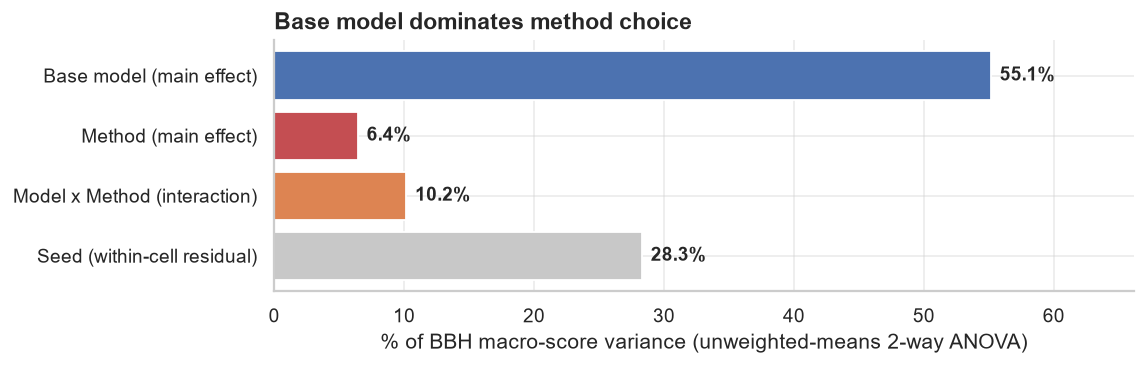

Base model (main effect)        55.1
Method (main effect)             6.4
Model x Method (interaction)    10.2
Seed (within-cell residual)     28.3

Best method per model:
                Method      mean
model                           
Qwen3-4B         GAAPO  0.686957
Qwen3-4B (pop8)   APEX  0.702899
Llama-3.2-3B     SWIFT  0.558696
Phi-4-mini       SWIFT  0.667391
Gemma3-4B         CAPO  0.647101
Llama-3.1-8B     SWIFT  0.610870
Gemma-7B         SWIFT  0.605797
Qwen3-8B           SEE  0.693478

Best 4B score seen: 0.703 (Qwen3-4B (pop8))  |  Best 8B score seen: 0.693 (Qwen3-8B)
4B models beating the weaker 8B models despite half the parameters would indicate training recipe outweighs scale -- compare the two lists above directly.


In [9]:
cells = (macro.groupby(["model", "method"]).macro.agg(["mean", "count"])
         .rename(columns={"mean": "cell_mean", "count": "n"}).reset_index())
grand2 = cells.cell_mean.mean()
row_means = cells.groupby("model").cell_mean.mean()
col_means = cells.groupby("method").cell_mean.mean()

ss_model2 = sum(len(cells[cells.model == m]) * (row_means[m] - grand2) ** 2 for m in row_means.index)
ss_method2 = sum(len(cells[cells.method == mth]) * (col_means[mth] - grand2) ** 2 for mth in col_means.index)
ss_interaction2 = sum(
    r.n * ((r.cell_mean - row_means[r.model] - col_means[r.method] + grand2) ** 2)
    for _, r in cells.iterrows())
cell_lookup = cells.set_index(["model", "method"]).cell_mean
ss_within2 = sum((row.macro - cell_lookup[(row.model, row.method)]) ** 2
                 for _, row in macro.iterrows()
                 if (row.model, row.method) in cell_lookup.index)
sst2 = ss_model2 + ss_method2 + ss_interaction2 + ss_within2

anova2 = pd.Series({
    "Base model (main effect)": ss_model2 / sst2 * 100,
    "Method (main effect)": ss_method2 / sst2 * 100,
    "Model x Method (interaction)": ss_interaction2 / sst2 * 100,
    "Seed (within-cell residual)": ss_within2 / sst2 * 100,
})
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(anova2.index[::-1], anova2.values[::-1],
        color=["#c8c8c8", "#dd8452", "#c44e52", "#4c72b0"], edgecolor="white")
for y_, v_ in enumerate(anova2.values[::-1]):
    ax.annotate(f"{v_:.1f}%", (v_, y_), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=10.5, fontweight="bold")
ax.set_xlabel("% of BBH macro-score variance (unweighted-means 2-way ANOVA)")
ax.set_title("Base model dominates method choice", loc="left")
ax.set_xlim(0, max(anova2.values) * 1.2)
tl(); plt.show()
print(anova2.round(1).to_string())

best_per_model = tbl.loc[tbl.groupby("model")["mean"].idxmax()][["model", "Method", "mean"]]
best_per_model = best_per_model.set_index("model").reindex(models_present)
print("\nBest method per model:")
print(best_per_model.to_string())
size4b = [m for m in models_present if SIZE_CLASS.get(m) == "4B"]
size8b = [m for m in models_present if SIZE_CLASS.get(m) == "8B"]
if size4b and size8b:
    b4 = tbl[tbl.model.isin(size4b)].groupby("model")["mean"].max()
    b8 = tbl[tbl.model.isin(size8b)].groupby("model")["mean"].max()
    print(f"\nBest 4B score seen: {b4.max():.3f} ({b4.idxmax()})  |  "
          f"Best 8B score seen: {b8.max():.3f} ({b8.idxmax()})")
    print("4B models beating the weaker 8B models despite half the parameters would indicate "
          "training recipe outweighs scale -- compare the two lists above directly.")

---
## 5 · Scoped check — GSM8K & HumanEval *(RQ1, narrower scope)*

**Only two models have clean, complete 6-method coverage on these benchmarks** (see the coverage table in §1) — this section is deliberately narrow rather than implying a generalization the data doesn't support.

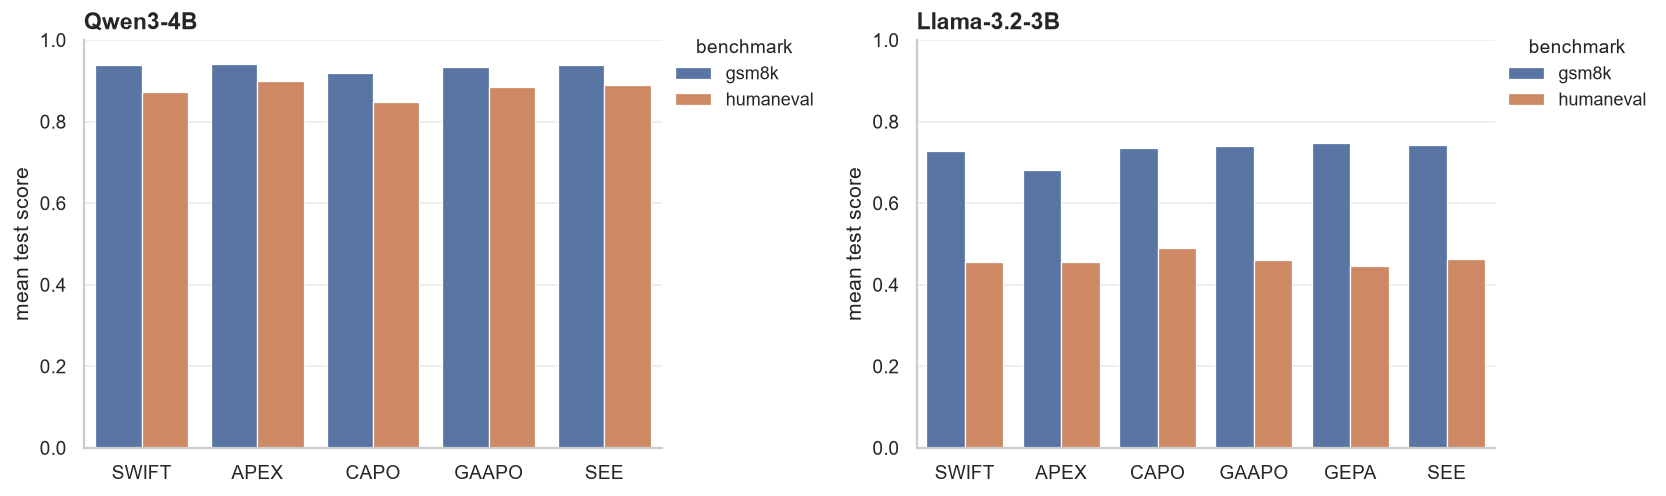

mean    std
model        benchmark Method              
Llama-3.2-3B gsm8k     APEX    0.681  0.050
                       CAPO    0.736  0.050
                       GAAPO   0.739  0.045
                       GEPA    0.748  0.031
                       SEE     0.742  0.070
                       SWIFT   0.728  0.074
             humaneval APEX    0.455  0.022
                       CAPO    0.490  0.066
                       GAAPO   0.461  0.026
                       GEPA    0.446  0.018
                       SEE     0.464  0.074
                       SWIFT   0.455  0.103
Qwen3-4B     gsm8k     APEX    0.942  0.013
                       CAPO    0.919  0.005
                       GAAPO   0.933  0.020
                       SEE     0.939  0.017
                       SWIFT   0.939  0.017
             humaneval APEX    0.899  0.013
                       CAPO    0.849  0.013
                       GAAPO   0.884  0.028
                       SEE     0.890  0.035
                       SWIFT   0.872  0.018

In [10]:
gh = runs[(runs.model.isin(GH_MODELS)) & (runs.benchmark.isin(["gsm8k", "humaneval"]))]
if gh.empty:
    print("No GSM8K/HumanEval data in scope.")
else:
    ghtbl = (gh.groupby(["model", "benchmark", "Method"])["test_score"]
             .agg(mean="mean", std="std").reset_index())
    fig, axes = plt.subplots(1, len(GH_MODELS), figsize=(6.5 * len(GH_MODELS), 4), squeeze=False)
    for ax, model in zip(axes[0], GH_MODELS):
        sub = ghtbl[ghtbl.model == model]
        method_order = [METHOD_LABEL[m] for m in METHODS if METHOD_LABEL[m] in sub.Method.unique()]
        sns.barplot(data=sub, x="Method", y="mean", hue="benchmark", order=method_order,
                    ax=ax, edgecolor="white", linewidth=0.7)
        ax.set_title(model, loc="left"); ax.set_xlabel(""); ax.set_ylabel("mean test score")
        ax.set_ylim(0, 1.0)
        legend_right(ax, title="benchmark")
    tl(); plt.show()
    display(ghtbl.round(3).set_index(["model", "benchmark", "Method"]))

---
## 6 · SWIFT vs. APEX: fixed schedule or adaptive bandit? *(RQ4)*

**Question: at this budget, does learning the operator allocation online (APEX's UCB1 bandit) beat a hand-curated fixed order (SWIFT)?** SWIFT and APEX share every component except scheduling, so this is the cleanest head-to-head in the study. Best-dev-score-so-far against wall-clock time, averaged over all complete (model, task, seed) runs.

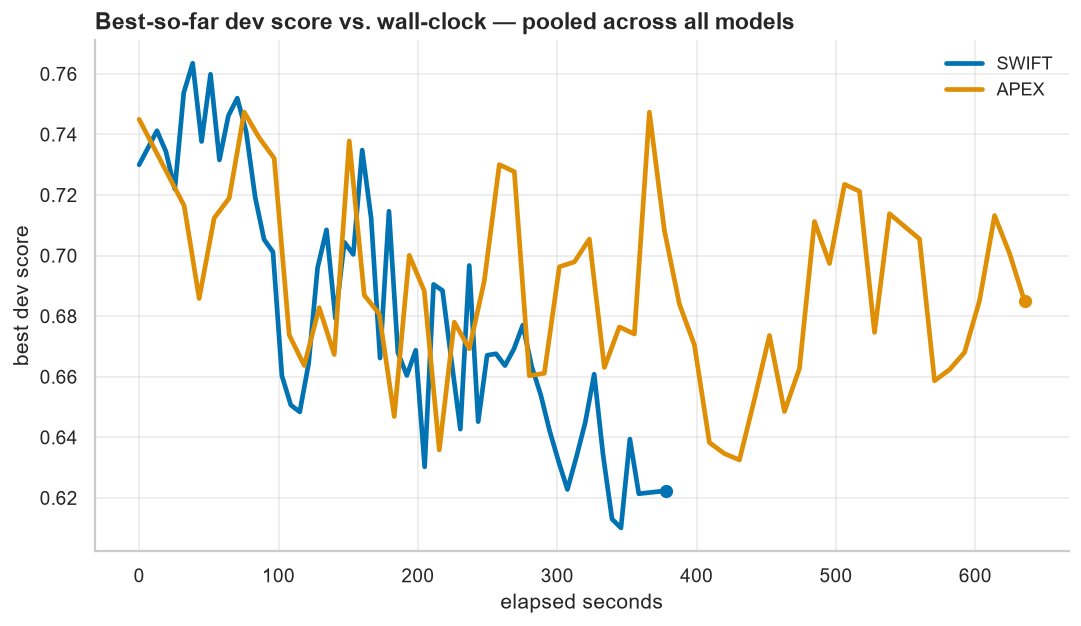

Normalized anytime AUC (1.0 = final quality reached immediately):
         mean    std
Method              
APEX    1.000  0.132
SWIFT   1.101  0.120


In [11]:
def anytime_curves(traj_df):
    rows = []
    for (model, method, task, seed), g in traj_df.groupby(["model", "method", "task", "seed"]):
        g = g.sort_values("generation")
        ts = pd.to_datetime(g.timestamp, errors="coerce")
        if ts.isna().any() or len(g) < 2:
            continue
        el = (ts - ts.iloc[0]).dt.total_seconds().values
        best = np.maximum.accumulate(g.best_score.values)
        for e, b in zip(el, best):
            rows.append(dict(model=model, method=method, elapsed=e, best=b))
    return pd.DataFrame(rows)

sub_traj = traj[(traj.benchmark == "bbh") & (traj.model.isin(models_present)) &
                (traj.method.isin(["swift", "apex"]))]
any_df = anytime_curves(sub_traj)

if any_df.empty:
    print("No trajectory data available for SWIFT/APEX.")
else:
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for m in ["swift", "apex"]:
        s = any_df[any_df.method == m]
        if s.empty:
            continue
        grid = np.linspace(0, s.groupby("model").elapsed.max().median(), 60)
        curves = []
        for _, gg in s.groupby(["model"]):
            gg = gg.sort_values("elapsed")
            curves.append(np.interp(grid, gg.elapsed, gg.best))
        mc = np.mean(curves, axis=0)
        ax.plot(grid, mc, label=METHOD_LABEL[m], color=PALETTE[m], lw=2.6)
        ax.scatter(grid[-1], mc[-1], color=PALETTE[m], s=40, zorder=3)
    ax.set_title("Best-so-far dev score vs. wall-clock \u2014 pooled across all models", loc="left")
    ax.set_xlabel("elapsed seconds"); ax.set_ylabel("best dev score")
    ax.legend(frameon=False)
    tl(); plt.show()

    aucs = []
    for (model, method), gg in any_df.groupby(["model", "method"]):
        gg = gg.sort_values("elapsed")
        if gg.elapsed.iloc[-1] <= 0:
            continue
        x = gg.elapsed / gg.elapsed.iloc[-1]
        y = gg.best / gg.best.iloc[-1] if gg.best.iloc[-1] > 0 else gg.best
        trap = getattr(np, "trapezoid", None) or np.trapz
        aucs.append(dict(Method=METHOD_LABEL[method], auc=trap(y, x)))
    aucs = pd.DataFrame(aucs)
    print("Normalized anytime AUC (1.0 = final quality reached immediately):")
    print(aucs.groupby("Method").auc.agg(["mean", "std"]).round(3).to_string())

---
## 7 · Findings & limitations

Auto-generated from the current data state below, then interpreted.

In [12]:
print("=" * 70)
print("SUMMARY -- generated from current data")
print("=" * 70)
if best_cfg:
    print(f"\nPooled CD ranking ({len(X)} blocks, {len(labels)} methods): "
          f"{' > '.join(avg_rank.index)}  (Friedman p={p:.4f})")
    print(f"Bradley-Terry ranking: {' > '.join(labels[i] for i in order)}")
print(f"\nCheapest method (mean calls/run): {eff.loc[eff.calls.idxmin(), 'Method']}")
print(f"Most accurate method (pooled BBH): {eff.loc[eff.acc.idxmax(), 'Method']}")
print(f"\nModel x Method interaction share of variance: {ss_interaction2/sst2*100:.1f}%  "
      f"({'best method depends on the base model' if ss_interaction2/sst2 > 0.10 else 'best method is fairly stable across models'})")
print(f"Base model explains {ss_model2/sst2*100:.1f}% of BBH variance vs. "
      f"{ss_method2/sst2*100:.1f}% for method choice -- "
      f"{'model choice dominates' if ss_model2 > ss_method2 else 'method choice dominates'}.")
if not aucs.empty:
    swift_auc = aucs[aucs.Method == 'SWIFT'].auc.mean()
    apex_auc = aucs[aucs.Method == 'APEX'].auc.mean()
    print(f"\nAnytime AUC -- SWIFT {swift_auc:.3f} vs. APEX {apex_auc:.3f} "
          f"({'SWIFT' if swift_auc > apex_auc else 'APEX'} surfaces good prompts earlier)")

print("\n--- Not covered by this notebook (disclosed, not silently omitted) ---")
print("  - SVAMP: zero data anywhere in outputs/ -- excluded entirely, not fabricated")
print("  - GEPA on the primary Qwen3-4B study: method never run there; handled via the")
print("    config-A/config-B fallback in \u00a7 2, not silently dropped")
print(f"  - \"Qwen3-4B (pop8)\" (qwen3-4b-instruct-2507): same checkpoint as Qwen3-4B but a "
      f"different\n    population_size/num_iterations config -- kept as its own column, "
      f"never merged with\n    \"Qwen3-4B\", so the two remain separately comparable")
print("  - 8-task extended BBH set: complete for 2 of 8 models so far, shown in \u00a72.1's "
      "per-task tables only")
missing = {m: [METHOD_LABEL[x] for x in METHODS if x not in complete_bbh.get(m, [])]
           for m in models_present}
for m, miss in missing.items():
    if miss:
        print(f"  - {m}: BBH incomplete for {miss}")
for m in MODEL_ORDER:
    if m not in models_present:
        print(f"  - {m}: no data yet")


SUMMARY -- generated from current data

Pooled CD ranking (40 blocks, 5 methods): SWIFT > GAAPO > CAPO > APEX > SEE  (Friedman p=0.1984)
Bradley-Terry ranking: SWIFT > GAAPO > CAPO > APEX > SEE

Cheapest method (mean calls/run): GEPA
Most accurate method (pooled BBH): APEXv2

Model x Method interaction share of variance: 10.2%  (best method depends on the base model)
Base model explains 55.1% of BBH variance vs. 6.4% for method choice -- model choice dominates.

Anytime AUC -- SWIFT 1.101 vs. APEX 1.000 (SWIFT surfaces good prompts earlier)

--- Not covered by this notebook (disclosed, not silently omitted) ---
  - SVAMP: zero data anywhere in outputs/ -- excluded entirely, not fabricated
  - GEPA on the primary Qwen3-4B study: method never run there; handled via the
    config-A/config-B fallback in § 2, not silently dropped
  - "Qwen3-4B (pop8)" (qwen3-4b-instruct-2507): same checkpoint as Qwen3-4B but a different
    population_size/num_iterations config -- kept as its own column, n

**RQ1 — Outcome.** No single method dominates every model; the pooled CD diagram and Bradley-Terry ranking above give the two complementary, statistically-grounded answers for "best on average," and §4's per-model table shows exactly where that changes.

**RQ2 — Cost.** The methods differ far more in cost than in accuracy — the Pareto frontier in §3 shows which methods are actually worth their price, not just which is cheapest.

**RQ3 — Generalization.** §4's variance decomposition gives a direct, quantitative answer to "does base-model choice matter more than optimizer choice" — read the two percentages next to each other, not in isolation.

**RQ4 — Mechanism.** SWIFT and APEX isolate the one head-to-head scheduling question the study was designed to answer; §6's anytime curve and AUC are the direct evidence, not a proxy for it.
